<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment-Week-1/blob/main/assignment%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np

img_1 = cv2.imread('/content/alexander-lunyov-Hdzn_gIdh1o-unsplash.jpg')
img_2 = cv2.imread('/content/evgeni-tcherkasski-c659bBmJpw0-unsplash.jpg')
img_3 = cv2.imread('/content/micah-boswell-00nHr1Lpq6w-unsplash.jpg')
img_4 = cv2.imread('/content/stefan-stefancik-QXevDflbl8A-unsplash.jpg')

In [5]:
images = {'img_1': img_1, 'img_2': img_2, 'img_3': img_3, 'img_4': img_4}

for name, img in images.items():
    print(f"\n--- Statistics for {name} ---")
    print("Shape:", img.shape)
    print("Data type:", img.dtype)
    print("Min pixel:", img.min())
    print("Max pixel:", img.max())
    print("Mean pixel:", img.mean())


--- Statistics for img_1 ---
Shape: (960, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean pixel: 105.6062158203125

--- Statistics for img_2 ---
Shape: (427, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean pixel: 92.17393881733021

--- Statistics for img_3 ---
Shape: (853, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 251
Mean pixel: 130.3700945193435

--- Statistics for img_4 ---
Shape: (959, 640, 3)
Data type: uint8
Min pixel: 0
Max pixel: 243
Mean pixel: 83.69519410410149


In [16]:
# --- Define kernels --
# 1. Box blur (averaging)
kernel_blur = np.ones((5, 5), np.float32) / 25
# 3. Sobel edge detection (X direction)
kernel_sobel_x = np.array([[-1, 0, 1],
[-2, 0, 2],
[-1, 0, 1]], dtype=np.float32)
# 4. Laplacian edge detection
kernel_laplacian = np.array([[0,  1, 0],
[1, -4, 1],
[0,  1, 0]], dtype=np.float32)
# 5. Sharpening
kernel_sharpen = np.array([[ 0, -1,  0],
[-1,  5, -1],
[ 0, -1,  0]], dtype=np.float32)

In [9]:
gray = cv2.cvtColor(img_1, cv2.COLOR_BGR2GRAY)

blurred    = cv2.filter2D(gray, -1, kernel_blur)
gaussian   = cv2.GaussianBlur(gray, (5, 5), 0)
edge_x     = cv2.filter2D(gray, -1, kernel_sobel_x)
laplacian  = cv2.filter2D(gray, -1, kernel_laplacian)
sharpened  = cv2.filter2D(gray, -1, kernel_sharpen)


--- Processing img_1 ---


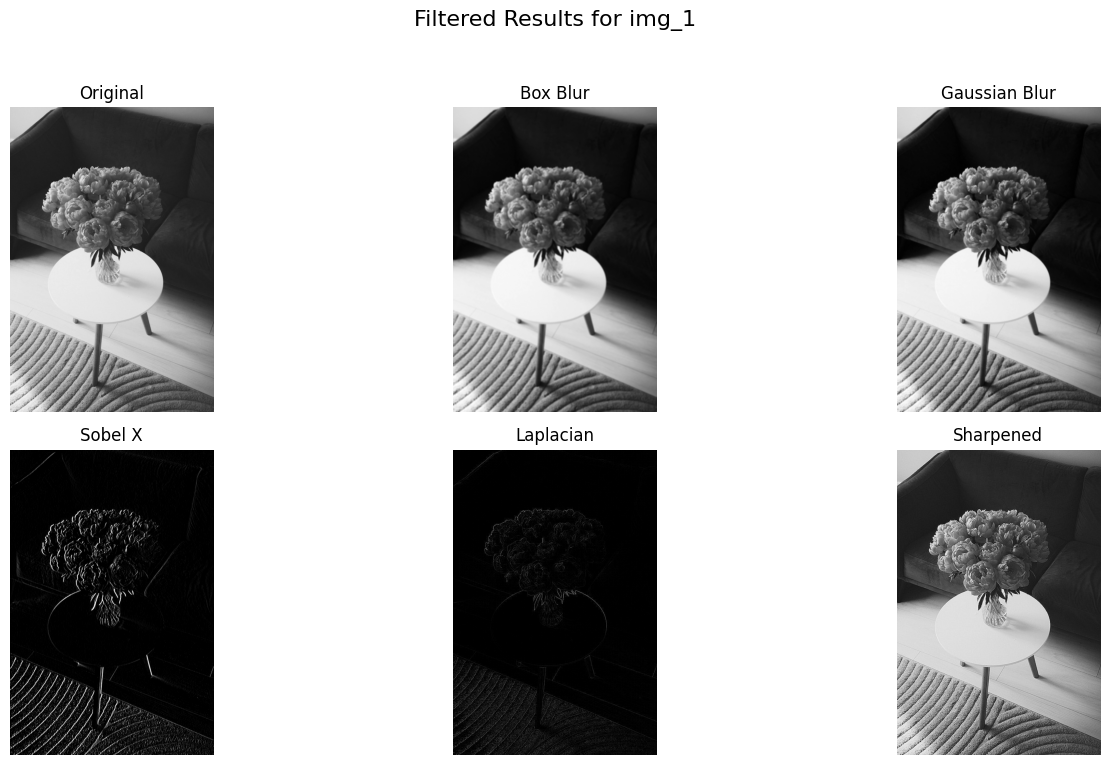


--- Processing img_2 ---


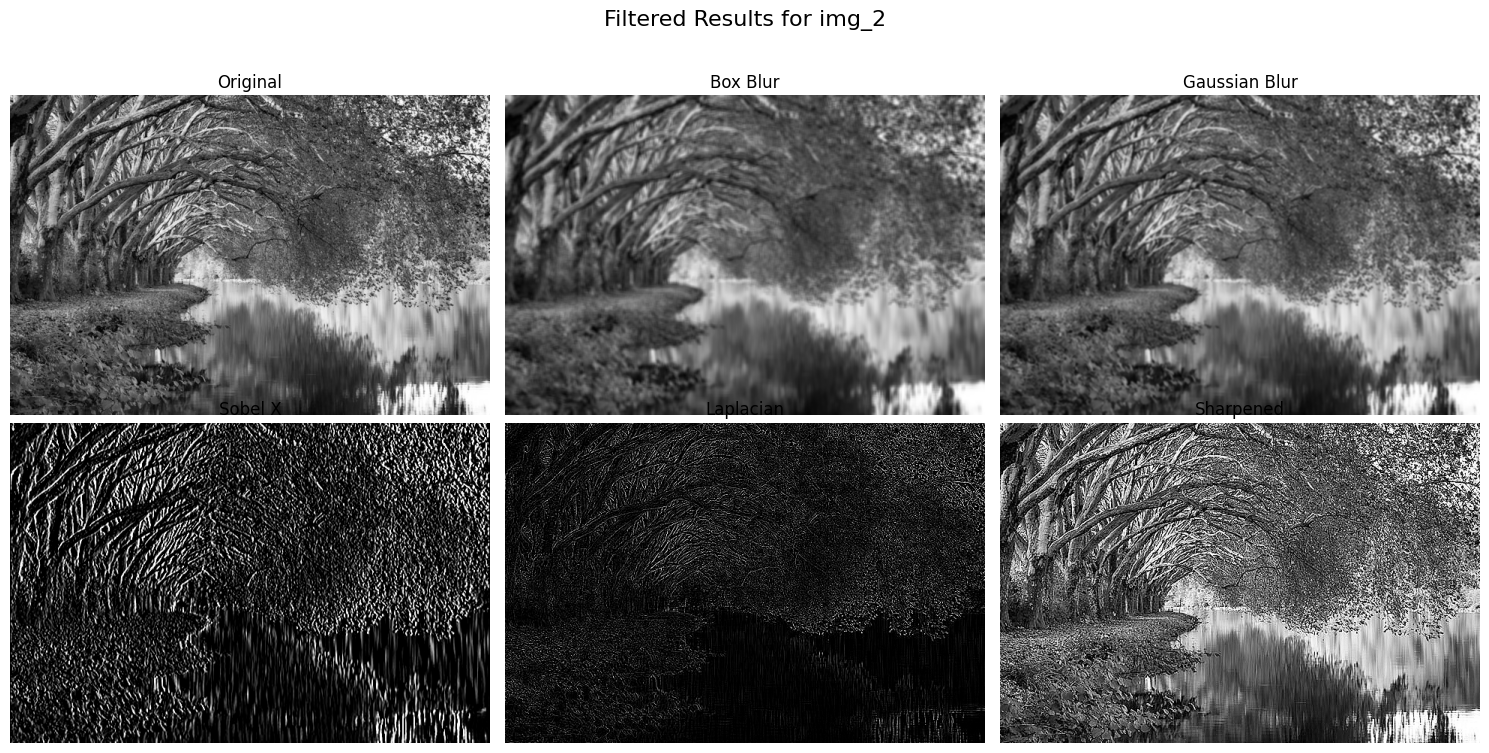


--- Processing img_3 ---


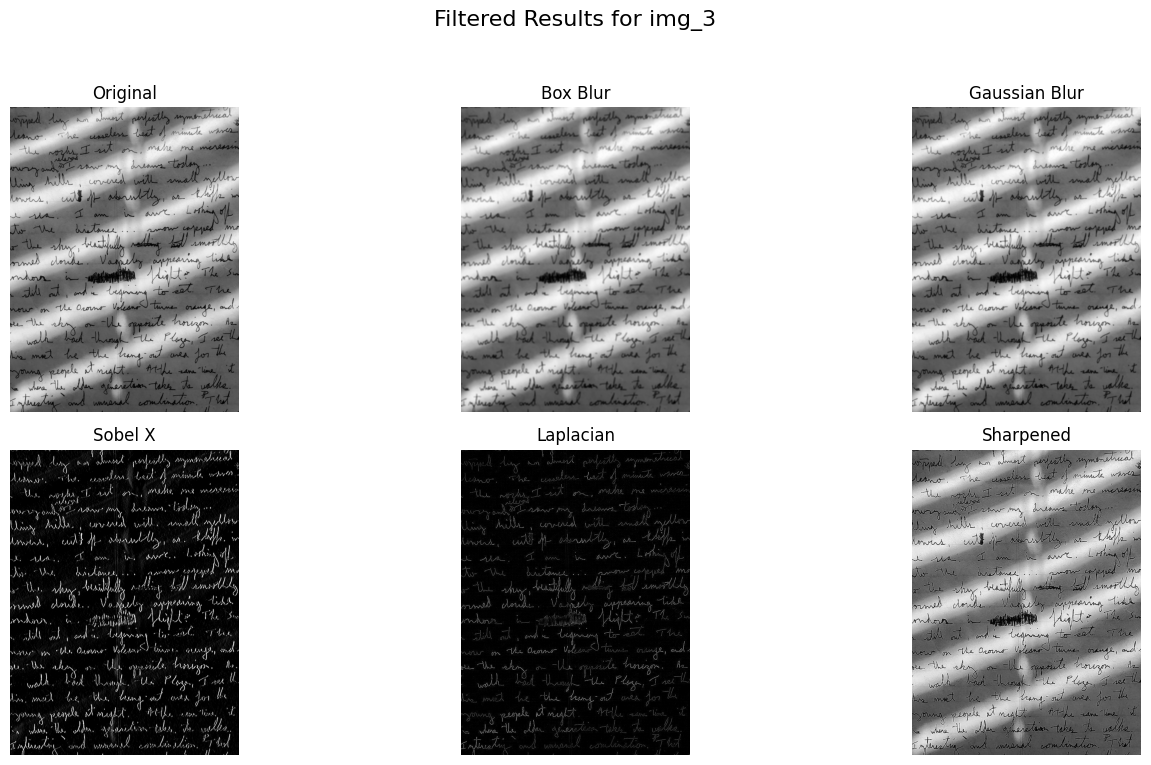


--- Processing img_4 ---


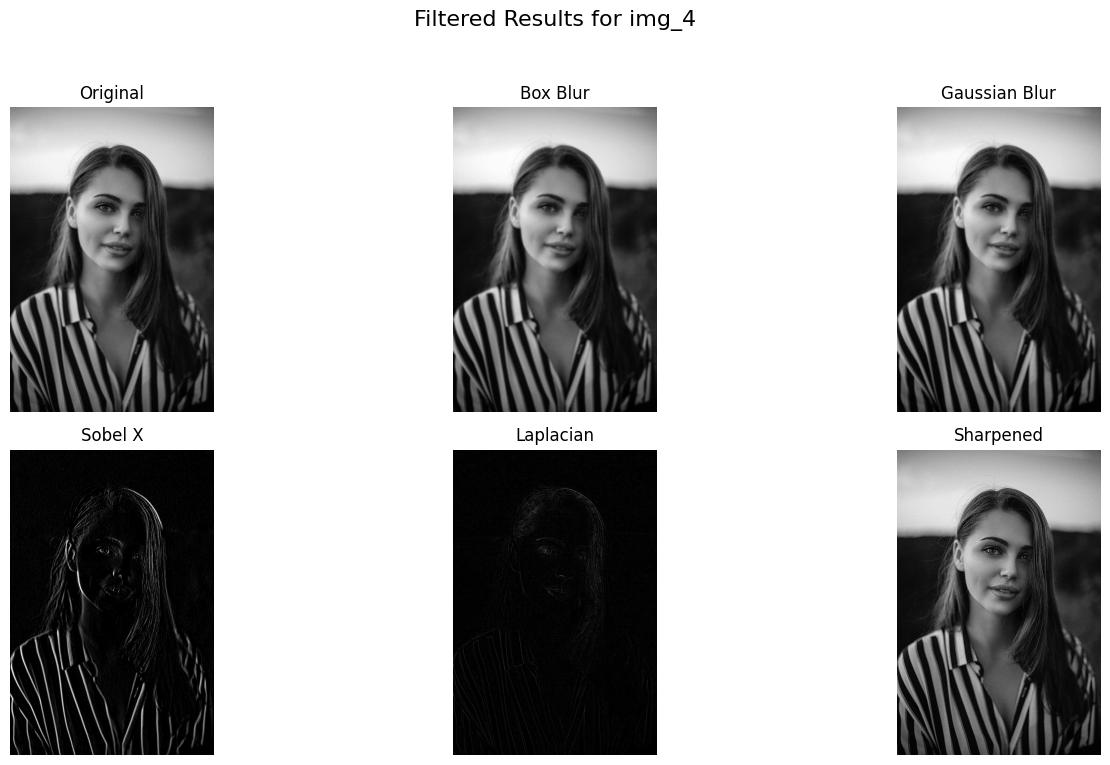

In [15]:
image_list = {'img_1': img_1, 'img_2': img_2, 'img_3': img_3, 'img_4': img_4}

titles  = ['Original', 'Box Blur', 'Gaussian Blur', 'Sobel X', 'Laplacian', 'Sharpened']

for name, current_img in image_list.items():
    print(f"\n--- Processing {name} ---")
    current_gray = cv2.cvtColor(current_img, cv2.COLOR_BGR2GRAY)

    # Apply all defined filters
    blurred    = cv2.filter2D(current_gray, -1, kernel_blur)
    gaussian   = cv2.GaussianBlur(current_gray, (5, 5), 0)
    edge_x     = cv2.filter2D(current_gray, -1, kernel_sobel_x)
    laplacian  = cv2.filter2D(current_gray, -1, kernel_laplacian)
    sharpened  = cv2.filter2D(current_gray, -1, kernel_sharpen)

    images_to_display  = [current_gray, blurred, gaussian, np.abs(edge_x).astype(np.uint8),
                           np.abs(laplacian).astype(np.uint8), sharpened]

    plt.figure(figsize=(15, 8))
    plt.suptitle(f'Filtered Results for {name}', fontsize=16)
    for i, (t, im) in enumerate(zip(titles, images_to_display)):
        plt.subplot(2, 3, i+1)
        plt.imshow(im, cmap='gray')
        plt.title(t)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

for `img_1` (the landscape image),
the Gaussian Blur provided a natural softening effect, enhancing the serene quality without losing too much detail.

for `img_2` (another landscape/nature shot),
the Box Blur offered a gentle artistic abstraction, smoothing harsh details while maintaining the overall scene's composition.

For `img_3` (the document),
the Laplacian filter clearly highlighted the text edges, making the document content more defined and readable by emphasizing boundaries.

For `img_4` (the portrait), sharpening was particularly effective in bringing out facial features and hair textures, adding crispness.